# Day 049 — Feature Selection Techniques
**AI/ML 365-Day Roadmap — Sahil Kumar**

---

## Why Feature Selection?
- Removes irrelevant/redundant features → simpler model, faster training
- Reduces overfitting (fewer features = less noise to memorize)
- Improves model interpretability
- Reduces the **Curse of Dimensionality** — in high dimensions, data becomes sparse and distances lose meaning

---

## 1. Filter Methods (Statistical Scoring — Model Independent)

Score each feature independently using statistical tests, then keep top-K.

### A. Pearson Correlation
- Measures **linear** relationship between feature and target
- Range: [-1, +1]. Use `abs()` for importance magnitude
- ⚠️ Only captures **linear** relationships — misses non-linear patterns

```python
# Compute correlation with target
correlations = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
# Keep features with |corr| > 0.1 (threshold is your choice)
selected = correlations[correlations > 0.1].index.tolist()
```

### B. Mutual Information
- Captures **both linear AND non-linear** relationships
- Based on information theory — how much knowing X reduces uncertainty about Y
- Range: [0, ∞). Higher = more informative

### C. ANOVA F-test (f_classif)
- Tests whether the means of a feature differ across classes
- Higher F-score = feature separates classes better
- Assumes features are normally distributed (approximate is fine)

### D. Chi-Squared Test
- For **categorical features** vs **categorical target**
- Tests independence between feature and target
- ⚠️ Only works on non-negative values

### SelectKBest Syntax:
```python
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2

# ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=10)  # Keep top 10 features
X_selected = selector.fit_transform(X, y)

# Get scores and selected feature names
scores = selector.scores_           # F-scores per feature
mask = selector.get_support()       # Boolean mask of selected features
selected_names = X.columns[mask]    # If X is DataFrame

# Mutual Information (captures non-linear too)
selector_mi = SelectKBest(score_func=mutual_info_classif, k=10)
```

---

## 2. Wrapper Methods (Use Model Performance to Select)

### A. RFE (Recursive Feature Elimination)
- Trains model → ranks features by importance → removes **least important** → repeats
- Stops when desired number of features reached
- ⚠️ Slow — trains model N times (one per removed feature)

```python
from sklearn.feature_selection import RFE

rfe = RFE(
    estimator=LogisticRegression(max_iter=1000),  # Base model
    n_features_to_select=10,                       # How many to keep
    step=1                                         # Remove 1 feature per iteration
)
rfe.fit(X, y)

print(rfe.support_)    # Boolean mask: True = selected
print(rfe.ranking_)    # Ranking: 1 = selected, 2 = removed second-to-last, etc.
```

### B. RFECV (RFE + Cross-Validation)
- Like RFE but **automatically finds the optimal number of features** using CV
- Plots accuracy vs number of features → picks the peak
- **Gold standard** wrapper method

```python
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000),
    step=1,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    n_jobs=-1
)
rfecv.fit(X, y)

print(rfecv.n_features_)                       # Optimal feature count
print(rfecv.support_)                           # Boolean mask
print(rfecv.cv_results_['mean_test_score'])     # CV scores per feature count
# Plot: plt.plot(range(1, len(scores)+1), scores)
```

---

## 3. Embedded Methods (Feature Selection During Training)

### A. L1 (Lasso) Regularization
- L1 penalty forces some coefficients to **exactly zero** → automatic feature selection
- Non-zero coefficients = selected features
- Higher C = less regularization = more features kept

```python
from sklearn.linear_model import LogisticRegression

lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0)
lasso.fit(X, y)

# Features with non-zero coefficients are selected
coefs = np.abs(lasso.coef_[0])
selected = feature_names[coefs > 0]
zeroed = feature_names[coefs == 0]  # These were deemed useless by L1
```

### B. Tree-Based Feature Importance
- Random Forest / XGBoost calculate **Gini importance** (Mean Decrease in Impurity)
- Also: **Permutation Importance** (accuracy drop when feature is shuffled)
- ⚠️ Gini importance is **biased** toward high-cardinality features

### C. SelectFromModel
- Wraps any model that has `feature_importances_` or `coef_`
- Keeps features above a threshold (default: `threshold='mean'`)

```python
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

# Manual: inspect importances
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

# Automatic: SelectFromModel
sfm = SelectFromModel(rf, threshold='median')   # Keep above-median importance
sfm.fit(X, y)
X_selected = sfm.transform(X)
selected_features = feature_names[sfm.get_support()]
```

---

## Summary Comparison

| Category | Methods | Pros | Cons |
|---|---|---|---|
| **Filter** | Correlation, MI, F-test, Chi² | ⚡ Very fast, model-agnostic | Ignores feature interactions |
| **Wrapper** | RFE, RFECV | Best accuracy (uses model) | 🐢 Very slow |
| **Embedded** | L1, Tree importance, SelectFromModel | ⚡ Fast, captures interactions | Model-specific |

### Best Practice:
1. Start with **Filter** (quick screening)
2. Use **Embedded** (L1 or tree importance) for refinement
3. Use **RFECV** for final selection if compute budget allows
4. **Always integrate inside Pipeline** to prevent leakage!

---

## 🧪 Practice Tasks

1. Create dataset: `make_classification(n_samples=1000, n_features=20, n_informative=8, n_redundant=4, n_repeated=2)`
2. **Filter**: Compute Pearson correlation with target, plot bar chart, select features with |corr| > 0.1
3. **Filter**: Use `SelectKBest(f_classif, k=10)` and `SelectKBest(mutual_info_classif, k=10)`, compare scores
4. **Wrapper**: Run `RFE(LogisticRegression(), n_features_to_select=10)`, print rankings
5. **Wrapper**: Run `RFECV`, plot CV accuracy vs number of features, find optimal count
6. **Embedded**: Fit L1 Logistic Regression, print zero-coefficient features
7. **Embedded**: Fit Random Forest, plot feature importances as bar chart, use `SelectFromModel(threshold='median')`
8. Compare: How many features overlap across all methods?

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1. Dataset create karein (20 features total)
X_raw, y = make_classification(
    n_samples=1000, 
    n_features=20, 
    n_informative=8, 
    n_redundant=4, 
    n_repeated=2, 
    random_state=42
)

# Convert to pandas DataFrame
feature_names = [f"feature_{i}" for i in range(20)]
X = pd.DataFrame(X_raw, columns=feature_names)

# 2. Train-Test Split (Data Leakage Safe)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train Shape: {X_train.shape} | X_test Shape: {X_test.shape}")
print("Target Distribution in Train:\n", pd.Series(y_train).value_counts(normalize=True))

X_train Shape: (800, 20) | X_test Shape: (200, 20)
Target Distribution in Train:
 0    0.5025
1    0.4975
Name: proportion, dtype: float64


In [10]:
X

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
0,-1.901860,0.201106,1.168584,3.278469,-1.759978,-1.651414,0.928922,0.187761,-0.078507,-1.216907,-0.461255,-2.396335,-0.064024,2.121014,5.190361,0.617864,0.928922,-0.701029,-0.121019,-0.078507
1,0.950341,-0.806144,-0.092897,-0.395776,-1.099191,1.182302,0.087565,1.797347,0.143534,-1.009102,2.538700,-1.560612,0.208117,1.975620,4.293407,1.545517,0.087565,-0.321960,-0.817745,0.143534
2,-2.729813,-1.010915,-0.550078,-0.508861,1.023147,-4.763619,-0.924918,0.730879,-0.277264,-3.574349,-0.782074,-1.317209,-0.086669,-2.949262,-0.911014,1.541028,-0.924918,-0.184099,-0.446745,-0.277264
3,-1.051254,1.108576,-0.562959,0.777249,0.297704,-2.678946,-0.509338,-0.823857,-0.965576,-5.593200,3.264538,-4.418624,-0.095323,0.858395,7.847714,3.021510,-0.509338,0.295605,-2.780644,-0.965576
4,-2.097810,0.495146,0.424264,0.082976,0.987453,-0.851447,0.327087,1.114233,0.589621,1.282813,-0.940530,-0.687646,1.833437,0.803222,-2.232531,-1.339921,0.327087,0.188283,1.028542,0.589621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.730806,-1.076728,0.533635,0.728024,0.549392,-3.096355,3.918552,1.641537,-1.280843,-0.838328,-2.945835,-2.779757,-1.891304,-2.360931,0.053896,0.785334,3.918552,-0.045974,-0.973197,-1.280843
996,-1.138081,-1.863220,1.031544,1.186222,0.662306,0.645623,0.066485,0.038044,-0.708928,2.411691,-0.721115,-0.870199,1.710755,0.552127,-2.333199,-3.254388,0.066485,0.368617,-1.644598,-0.708928
997,-0.119519,-0.028992,0.554732,1.518979,-0.776869,1.954024,5.490168,-0.867582,-1.214203,0.027160,-2.435595,-1.153934,-0.877622,1.910285,0.870572,-3.017584,5.490168,-0.389463,-0.874844,-1.214203
998,-0.048945,0.360221,0.038480,0.228515,-0.610911,2.300640,-0.202382,-0.386988,0.909789,1.021118,0.658436,0.644952,-1.210543,2.887271,0.516634,-1.453019,-0.202382,-1.068136,0.508048,0.909789


In [11]:
y

array([1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,

In [14]:
train_df=pd.concat([X_train,pd.Series(y_train,name='target')],axis=1)

In [15]:
corr=train_df.corr()['target'].drop('target')

In [24]:
train_df = X_train.copy()
train_df['target'] = y_train

In [25]:
corr=train_df.corr()['target']

In [28]:
import seaborn as sns

<Axes: xlabel='target', ylabel='Count'>

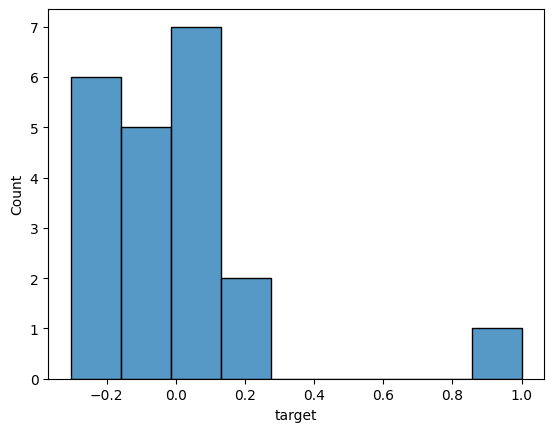

In [30]:
sns.histplot(corr)

In [31]:
corr = train_df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print(corr)

feature_5     0.304206
feature_13    0.260761
feature_0     0.238541
feature_16    0.224525
feature_6     0.224525
feature_11    0.215474
feature_10    0.208937
feature_14    0.181494
feature_19    0.085478
feature_8     0.085478
feature_3     0.053826
feature_12    0.050516
feature_4     0.038136
feature_9     0.038111
feature_18    0.032842
feature_2     0.028372
feature_15    0.023037
feature_17    0.014827
feature_7     0.012102
feature_1     0.011617
Name: target, dtype: float64


<Axes: >

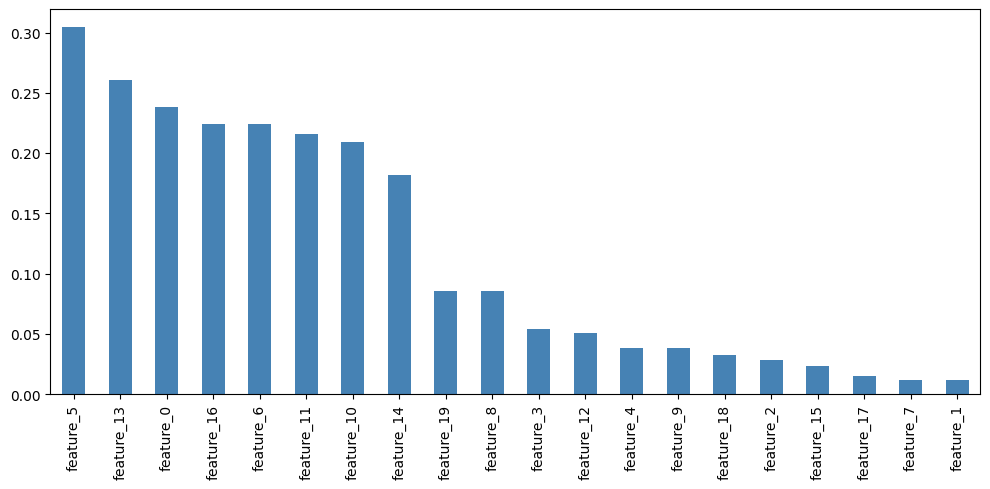

In [34]:
plt.figure(figsize=(12,5))
corr.plot(kind='bar',color='steelblue')


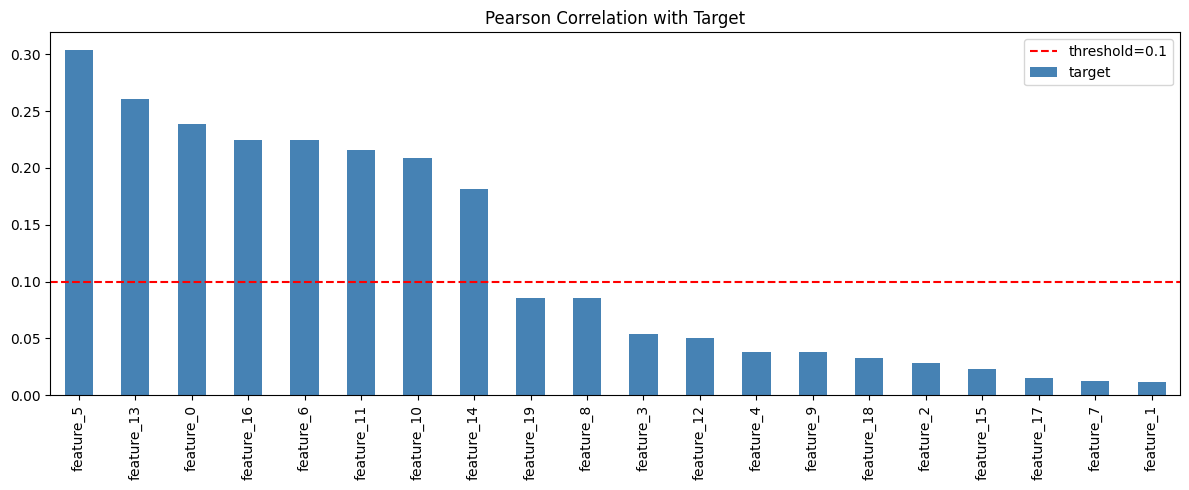

In [35]:
plt.figure(figsize=(12,5))
corr.plot(kind='bar', color='steelblue')
plt.axhline(0.1, color='red', linestyle='--', label='threshold=0.1')
plt.title("Pearson Correlation with Target")
plt.legend(); plt.tight_layout(); plt.show()

In [36]:
selected_by_corr = corr[corr > 0.1].index.tolist()
print(f"Selected ({len(selected_by_corr)}):", selected_by_corr)

Selected (8): ['feature_5', 'feature_13', 'feature_0', 'feature_16', 'feature_6', 'feature_11', 'feature_10', 'feature_14']


In [37]:
from sklearn.feature_selection import SelectKBest,f_classif,mutual_info_classif

In [38]:
f_selector=SelectKBest(score_func=f_classif,k=8).fit(X_train,y_train)

In [39]:
mi_selector=SelectKBest(score_func=mutual_info_classif,k=8).fit(X_train,y_train)

In [40]:
f_selected = set(X_train.columns[f_selector.get_support()])
mi_selected = set(X_train.columns[mi_selector.get_support()])

In [41]:
print("F-test:", sorted(f_selected))
print("MI:", sorted(mi_selected))

F-test: ['feature_0', 'feature_10', 'feature_11', 'feature_13', 'feature_14', 'feature_16', 'feature_5', 'feature_6']
MI: ['feature_0', 'feature_10', 'feature_11', 'feature_13', 'feature_14', 'feature_16', 'feature_5', 'feature_6']


In [42]:
from sklearn.feature_selection import RFE

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=8, step=1)
rfe.fit(X_train, y_train)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",8
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [45]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=8, step=1)
rfe.fit(X_train, y_train)

rfe_selected = X_train.columns[rfe.support_].tolist()
print("RFE selected:", rfe_selected)

RFE selected: ['feature_0', 'feature_5', 'feature_6', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_16']


In [46]:
from sklearn.feature_selection import RFECV

In [47]:
from sklearn.model_selection import StratifiedKFold

In [48]:
cv=StratifiedKFold(n_splits=4,shuffle=True,random_state=42)

In [49]:
rfecv=RFECV(estimator=LogisticRegression(),step=1,cv=cv)

In [50]:
rfecv.fit(X_train,y_train)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LogisticRegression()
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive f

In [52]:
rfecv.n_features_

np.int64(10)

In [53]:
print("Optimal count:", rfecv.n_features_)
rfecv_selected = X_train.columns[rfecv.support_].tolist()

Optimal count: 10


In [54]:
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
lasso.fit(X_train, y_train)

coefs = pd.Series(np.abs(lasso.coef_[0]), index=X_train.columns)
lasso_selected = coefs[coefs > 0].index.tolist()
print(f"Lasso selected ({len(lasso_selected)}):", lasso_selected)

Lasso selected (15): ['feature_0', 'feature_2', 'feature_3', 'feature_4', 'feature_6', 'feature_7', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_16', 'feature_17', 'feature_18']


C:\Users\sahil kumar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sahil kumar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)
sfm = SelectFromModel(rf, threshold='median', prefit=True)
rf_selected = X_train.columns[sfm.get_support()].tolist()
print(f"RF selected ({len(rf_selected)}):", rf_selected)

RF selected (10): ['feature_0', 'feature_5', 'feature_6', 'feature_9', 'feature_11', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_18']


feature_0     7
feature_14    7
feature_11    7
feature_6     7
feature_16    7
feature_13    7
feature_5     6
feature_10    4
feature_18    3
feature_12    3
feature_3     2
feature_9     2
feature_17    1
feature_2     1
feature_4     1
feature_7     1
feature_15    1
feature_1     0
feature_8     0
feature_19    0
dtype: int64


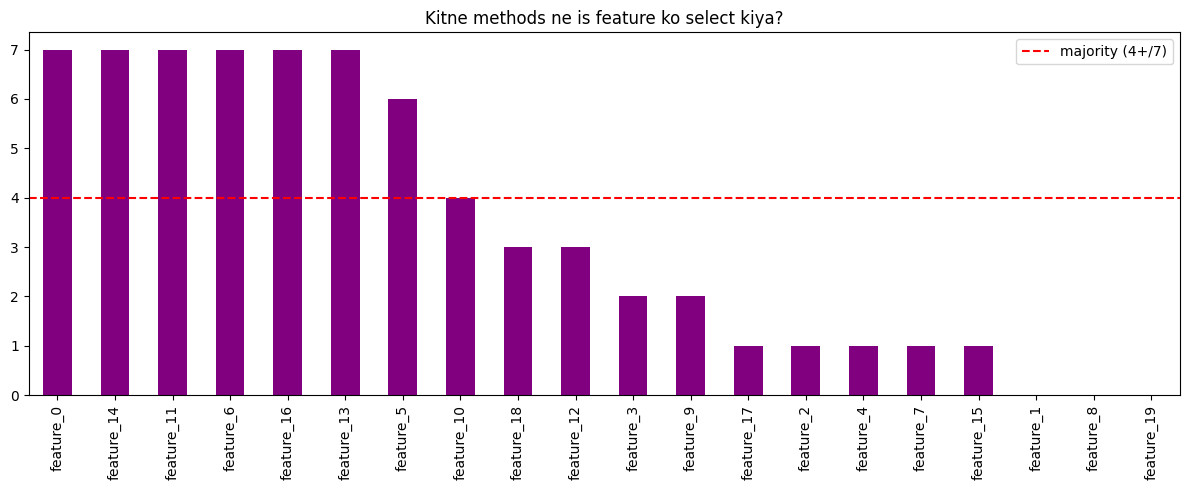

In [56]:
methods = {
    'Correlation': set(selected_by_corr), 'F-test': f_selected, 'MI': mi_selected,
    'RFE': set(rfe_selected), 'RFECV': set(rfecv_selected),
    'Lasso': set(lasso_selected), 'RandomForest': set(rf_selected),
}
vote_count = pd.Series(0, index=X_train.columns)
for feats in methods.values():
    for f in feats: vote_count[f] += 1
vote_count = vote_count.sort_values(ascending=False)
print(vote_count)

plt.figure(figsize=(12,5))
vote_count.plot(kind='bar', color='purple')
plt.axhline(4, color='red', linestyle='--', label='majority (4+/7)')
plt.title("Kitne methods ne is feature ko select kiya?")
plt.legend(); plt.tight_layout(); plt.show()